<a href="https://colab.research.google.com/github/thaiantl-code/hocsau/blob/main/Regis_Insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
# PyTorch
import torch

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Hiển thị đẹp hơn
plt.style.use('seaborn-v0_8')

In [3]:

# ============================================================
# LOAD DATASET
# ============================================================

#df = pd.read_csv("insurance.csv")

df = pd.read_csv("https://raw.githubusercontent.com/thaiantl-code/hocsau/refs/heads/main/insurance.csv")


# Hiển thị 5 dòng đầu
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# ============================================================
# DATA OVERVIEW
# ============================================================

print("Shape of dataset:")
print(df.shape)

print("\nDataset information:")
print(df.info())

print("\nMissing values:")
print(df.isnull().sum())

print("\nStatistical summary:")
print(df.describe())

Shape of dataset:
(1338, 7)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None

Missing values:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Statistical summary:
               age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.0

In [5]:
# ============================================================
# ONE HOT ENCODING
# ============================================================

df = pd.get_dummies(
    df,
    columns=['sex', 'smoker', 'region'],
    drop_first=True
)

df.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [6]:
# ============================================================
# FEATURES AND TARGET
# ============================================================

X = df.drop('charges', axis=1)
y = df['charges']

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1338, 8)
y shape: (1338,)


In [7]:
# ============================================================
# TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1070, 8)
Test size: (268, 8)


In [8]:
# ============================================================
# FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
# ============================================================
# CONVERT TO TENSOR
# ============================================================

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

torch.Size([1070, 8])
torch.Size([1070, 1])


In [10]:
# ============================================================
# INITIALIZE PARAMETERS
# ============================================================

input_size = X_train.shape[1]

# Khởi tạo weights và bias
weights = torch.randn(
    input_size,
    1,
    requires_grad=True
)

bias = torch.randn(
    1,
    requires_grad=True
)

print("Weights shape:", weights.shape)
print("Bias shape:", bias.shape)

Weights shape: torch.Size([8, 1])
Bias shape: torch.Size([1])


In [11]:
# ============================================================
# TRAINING CONFIGURATION
# ============================================================

learning_rate = 0.01
epochs = 1000

losses = []

# ============================================================
# TRAINING LOOP
# ============================================================

for epoch in range(epochs):

    # --------------------------------------------------------
    # FORWARD PASS
    # --------------------------------------------------------

    y_pred = torch.matmul(X_train_tensor, weights) + bias

    # --------------------------------------------------------
    # COMPUTE LOSS
    # --------------------------------------------------------

    loss = torch.mean((y_pred - y_train_tensor) ** 2)

    # Lưu loss để vẽ biểu đồ
    losses.append(loss.item())

    # --------------------------------------------------------
    # BACKPROPAGATION
    # --------------------------------------------------------

    loss.backward()

    # --------------------------------------------------------
    # UPDATE PARAMETERS
    # --------------------------------------------------------

    with torch.no_grad():

        weights -= learning_rate * weights.grad
        bias -= learning_rate * bias.grad

    # --------------------------------------------------------
    # RESET GRADIENTS
    # --------------------------------------------------------

    weights.grad.zero_()
    bias.grad.zero_()

    # --------------------------------------------------------
    # PRINT LOSS
    # --------------------------------------------------------

    if (epoch + 1) % 100 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {loss.item():.4f}")

Epoch [100/1000] - Loss: 42784616.0000
Epoch [200/1000] - Loss: 37395896.0000
Epoch [300/1000] - Loss: 37282848.0000
Epoch [400/1000] - Loss: 37278544.0000
Epoch [500/1000] - Loss: 37277912.0000
Epoch [600/1000] - Loss: 37277740.0000
Epoch [700/1000] - Loss: 37277700.0000
Epoch [800/1000] - Loss: 37277688.0000
Epoch [900/1000] - Loss: 37277684.0000
Epoch [1000/1000] - Loss: 37277680.0000


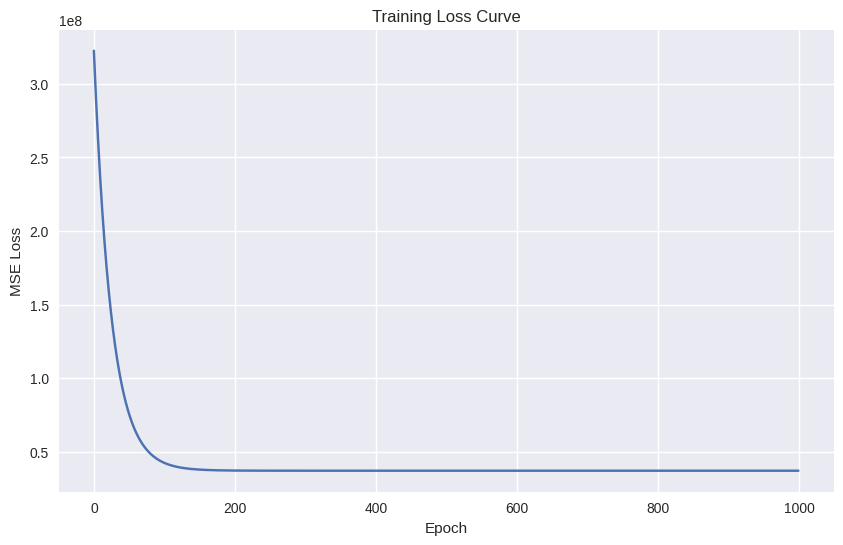

In [12]:
# ============================================================
# LOSS CURVE
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(losses)

plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.show()

In [13]:
# ============================================================
# PREDICTION
# ============================================================

with torch.no_grad():

    y_test_pred = torch.matmul(
        X_test_tensor,
        weights
    ) + bias

# Convert tensor -> numpy
y_pred_np = y_test_pred.numpy()
y_true_np = y_test_tensor.numpy()

In [14]:
# ============================================================
# EVALUATION METRICS
# ============================================================

mae = mean_absolute_error(y_true_np, y_pred_np)

mse = mean_squared_error(y_true_np, y_pred_np)

rmse = np.sqrt(mse)

r2 = r2_score(y_true_np, y_pred_np)

print("========== MODEL EVALUATION ==========")
print(f"MAE  : {mae:.4f}")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"R²   : {r2:.4f}")

========== MODEL EVALUATION ==========
MAE  : 4181.2178
MSE  : 33597340.0000
RMSE : 5796.3212
R²   : 0.7836


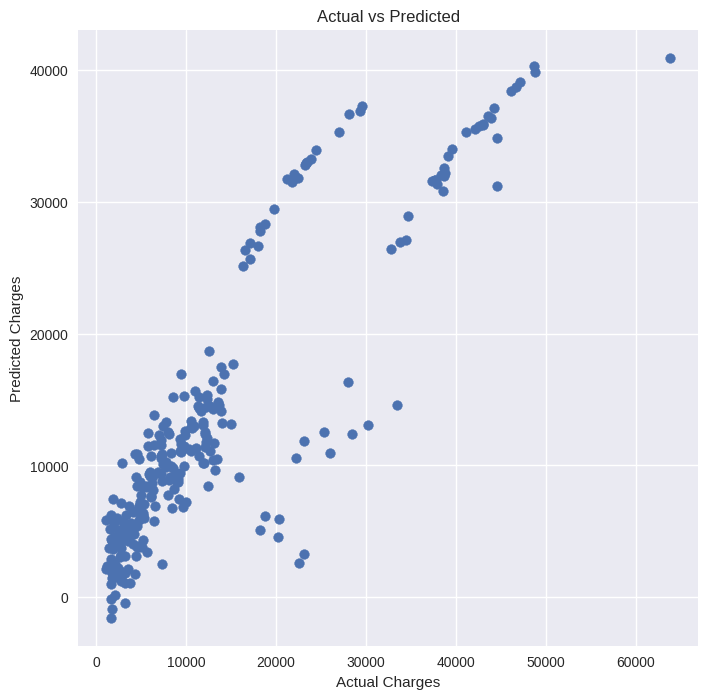

In [15]:
# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 8))

plt.scatter(y_true_np, y_pred_np)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted")

plt.show()